<a href="https://colab.research.google.com/github/sahiladvani993/AndroidStudio/blob/main/GenAi_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip -q install -U google-genai pandas numpy scipy scikit-learn openpyxl matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 22.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the

In [4]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("Gemini")

if not GEMINI_API_KEY:
    raise ValueError("Gemini API key not found.")

client = genai.Client(api_key=GEMINI_API_KEY)

print("Gemini client configured!")

Gemini client configured!


In [5]:
MODEL = "gemini-3.5-flash"

print("Model:", MODEL)

Model: gemini-3.5-flash


In [6]:
#Create the Gemini function
from google.genai import types
import time

def gemini_text(prompt, temperature=0.2):

    for attempt in range(4):

        try:

            response = client.models.generate_content(
                model=MODEL,
                contents=prompt,
                config=types.GenerateContentConfig(
                    temperature=temperature,
                    max_output_tokens=1800
                )
            )

            return response.text

        except Exception as e:

            error = str(e)

            if "503" in error or "UNAVAILABLE" in error:

                wait_time = 2 ** attempt

                print(
                    f"Gemini temporarily unavailable. "
                    f"Retrying in {wait_time} seconds..."
                )

                time.sleep(wait_time)

            else:
                raise e

    raise RuntimeError(
        "Gemini remained unavailable after multiple retries."
    )

print("Gemini function ready!")

Gemini function ready!


In [7]:
#Testing the Gemini model
response = client.models.generate_content(
    model=MODEL,
    contents="Say hello in one sentence."
)

print(response.text)

Hello, how can I help you today?


In [8]:
#Create / Load the Research Log
import numpy as np
import pandas as pd

np.random.seed(42)

n = 36

dates = pd.date_range(
    "2026-08-01",
    periods=n,
    freq="D"
)

df = pd.DataFrame({

    "date": dates,

    "experiment_id":
        [f"EXP-{100+i//6}" for i in range(n)],

    "sample_id":
        [f"S-{i+1:03d}" for i in range(n)],

    "condition":
        np.random.choice(
            ["Control", "Treatment-A", "Treatment-B"],
            n
        ),

    "replicate":
        np.tile([1,2,3], n//3 + 1)[:n],

    "temperature_c":
        np.random.normal(37.0, 0.35, n),

    "ph":
        np.random.normal(7.0, 0.12, n),

    "od600":
        np.random.normal(0.85, 0.12, n),

    "yield":
        np.random.normal(82, 7, n),

    "viability_pct":
        np.random.normal(94, 2.2, n),

    "result":
        np.random.choice(
            ["Pass", "Pass", "Pass", "Review"],
            n
        ),

    "notes":
        ["Routine run"] * n
})

In [10]:
#Add artificial anomalies
#We're deliberately adding some abnormal records so that our AI system has something to detect.

df.loc[7, "ph"] = np.nan

df.loc[18, "yield"] = 52

df.loc[27, "temperature_c"] = 39.5

df.loc[31, "viability_pct"] = 83

df.loc[10, "notes"] = "Unexpected deviation recorded"

df.loc[24, "notes"] = "Measurement repeated"

In [11]:
display(df.head())

,date,experiment_id,sample_id,condition,replicate,temperature_c,ph,od600,yield,viability_pct,result,notes
0,2026-08-01,EXP-100,S-001,Treatment-B,1,37.023635,7.039752,0.802947,71.145356,95.808532,Pass,Routine run
1,2026-08-02,EXP-100,S-002,Control,2,36.501338,7.117065,0.674378,82.479941,98.172945,Pass,Routine run
2,2026-08-03,EXP-100,S-003,Treatment-B,3,36.809466,6.942499,0.885534,74.563874,93.460146,Pass,Routine run
3,2026-08-04,EXP-100,S-004,Treatment-B,1,37.038823,6.977721,0.881327,85.315147,92.341780,Pass,Routine run
4,2026-08-05,EXP-100,S-005,Control,2,36.597152,6.867240,0.850614,75.564030,92.043068,Review,Routine run


In [12]:
#Normalize the research data
import re

def normalize_dataframe(data):

    data = data.copy()

    data.columns = [
        re.sub(
            r"[^a-z0-9_]+",
            "_",
            str(c).strip().lower()
        ).strip("_")
        for c in data.columns
    ]

    return data


df = normalize_dataframe(df)

print(df.columns.tolist())

['date', 'experiment_id', 'sample_id', 'condition', 'replicate', 'temperature_c', 'ph', 'od600', 'yield', 'viability_pct', 'result', 'notes']


In [16]:
# ==========================================
# FIXED DATA QUALITY AGENT
# ==========================================

import numpy as np
import pandas as pd
import json

def data_quality_agent(data):

    report = {
        "rows": int(len(data)),
        "columns": int(len(data.columns)),
        "missing_values": data.isna().sum().to_dict(),
        "duplicate_rows": int(data.duplicated().sum()),
        "numeric_summary": {},
        "outlier_rows": []
    }

    # Find numerical columns
    numeric_cols = data.select_dtypes(
        include=np.number
    ).columns.tolist()

    # --------------------------------------
    # Calculate statistics
    # --------------------------------------

    for col in numeric_cols:

        values = data[col].dropna()

        if len(values) > 0:

            report["numeric_summary"][col] = {
                "mean": float(values.mean()),
                "std": float(values.std()) if len(values) > 1 else 0.0,
                "min": float(values.min()),
                "max": float(values.max())
            }

    # --------------------------------------
    # Detect outliers using IQR
    # --------------------------------------

    for col in numeric_cols:

        values = data[col].dropna()

        if len(values) < 5:
            continue

        Q1 = values.quantile(0.25)
        Q3 = values.quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[
            (data[col] < lower_bound) |
            (data[col] > upper_bound)
        ]

        for index in outliers.index:

            if int(index) not in report["outlier_rows"]:
                report["outlier_rows"].append(int(index))

    return report


print("Fixed Data Quality Agent loaded!")

Fixed Data Quality Agent loaded!


In [17]:
quality_report = data_quality_agent(df)

print(
    json.dumps(
        quality_report,
        indent=2,
        default=str
    )
)

{
  "rows": 36,
  "columns": 12,
  "missing_values": {
    "date": 0,
    "experiment_id": 0,
    "sample_id": 0,
    "condition": 0,
    "replicate": 0,
    "temperature_c": 0,
    "ph": 1,
    "od600": 0,
    "yield": 0,
    "viability_pct": 0,
    "result": 0,
    "notes": 0
  },
  "duplicate_rows": 0,
  "numeric_summary": {
    "replicate": {
      "mean": 2.0,
      "std": 0.828078671210825,
      "min": 1.0,
      "max": 3.0
    },
    "temperature_c": {
      "mean": 37.004918535570916,
      "std": 0.5180556509354549,
      "min": 36.31411545664208,
      "max": 39.5
    },
    "ph": {
      "mean": 7.001279265154951,
      "std": 0.11141247636621093,
      "min": 6.68563058750923,
      "max": 7.187757238697681
    },
    "od600": {
      "mean": 0.8501856200672625,
      "std": 0.11915798267916183,
      "min": 0.619747454164115,
      "max": 1.1455890534982343
    },
    "yield": {
      "mean": 80.97014064321179,
      "std": 8.15011854690645,
      "min": 52.0,
      "max"

In [19]:
# ==========================================
# STATISTICS AGENT
# ==========================================

def statistics_agent(data):

    numeric = data.select_dtypes(
        include=np.number
    )

    result = {
        "correlations": {},
        "group_summaries": {}
    }

    # Correlation analysis
    if numeric.shape[1] >= 2:

        corr = numeric.corr().round(3)

        result["correlations"] = corr.to_dict()

    # Compare experimental conditions
    if "condition" in data.columns:

        metrics = [
            c for c in numeric.columns
            if c != "replicate"
        ]

        if metrics:

            grouped = (
                data
                .groupby("condition")[metrics]
                .mean()
                .round(3)
            )

            result["group_summaries"] = (
                grouped.to_dict()
            )

    return result


# Run Statistics Agent
stats_report = statistics_agent(df)

print("Statistics Agent completed!")

print(
    json.dumps(
        stats_report,
        indent=2,
        default=str
    )
)

Statistics Agent completed!
{
  "correlations": {
    "replicate": {
      "replicate": 1.0,
      "temperature_c": -0.215,
      "ph": -0.199,
      "od600": -0.111,
      "yield": 0.445,
      "viability_pct": 0.176
    },
    "temperature_c": {
      "replicate": -0.215,
      "temperature_c": 1.0,
      "ph": -0.024,
      "od600": 0.019,
      "yield": -0.039,
      "viability_pct": -0.184
    },
    "ph": {
      "replicate": -0.199,
      "temperature_c": -0.024,
      "ph": 1.0,
      "od600": 0.08,
      "yield": -0.1,
      "viability_pct": 0.145
    },
    "od600": {
      "replicate": -0.111,
      "temperature_c": 0.019,
      "ph": 0.08,
      "od600": 1.0,
      "yield": 0.018,
      "viability_pct": -0.18
    },
    "yield": {
      "replicate": 0.445,
      "temperature_c": -0.039,
      "ph": -0.1,
      "od600": 0.018,
      "yield": 1.0,
      "viability_pct": -0.017
    },
    "viability_pct": {
      "replicate": 0.176,
      "temperature_c": -0.184,
      "ph": 0

In [21]:
# ==========================================
# EXPERIMENTAL INTERPRETATION AGENT
# ==========================================

sample_for_llm = df.head(25).to_csv(index=False)

interpretation_prompt = f"""
You are the Experimental Interpretation Specialist Agent
in a biotechnology research-log analysis system.

Analyze the research-log data provided below.

IMPORTANT RULES:
- Do not invent measurements.
- Use only the supplied data.
- Separate observations from hypotheses.
- Do not provide wet-lab procedures.
- Do not make unsupported scientific conclusions.
- Focus on trends, anomalies and reproducibility.

RESEARCH LOG:
{sample_for_llm}

DATA QUALITY REPORT:
{json.dumps(quality_report, indent=2, default=str)}

STATISTICAL REPORT:
{json.dumps(stats_report, indent=2, default=str)}

Return your analysis using these sections:

## Key Observations

## Important Anomalies

## Possible Explanations

Clearly label possible explanations as hypotheses.

## Questions for the Researcher

## Data That Should Be Checked
"""

interpretation_report = gemini_text(
    interpretation_prompt,
    temperature=0.2
)

print(interpretation_report)

Here is the analysis of the provided research-log data and reports.

## Key Observations

* **Dataset Scale**: The research log contains 25 listed samples (S-001 to S-025) spanning five experiments (EXP-100 to EXP-104) from August 1 to August 2


In [23]:
# ==========================================
# RESEARCH QUALITY REVIEWER AGENT
# ==========================================

review_prompt = f"""
You are the Research Quality Reviewer Agent
for a biotechnology research laboratory.

Your job is to identify:
- documentation gaps
- data-quality problems
- reproducibility concerns
- records requiring human review

IMPORTANT:
- Do not invent information.
- Use only the supplied research log and quality report.
- Do not design experiments.
- Do not provide wet-lab procedures.
- Do not make final scientific conclusions.
- Flag issues that require a qualified researcher to verify.

RESEARCH LOG:
{df.head(30).to_csv(index=False)}

DETERMINISTIC QUALITY REPORT:
{json.dumps(quality_report, indent=2, default=str)}

Return the review using exactly these sections:

## 1. Documentation Gaps

## 2. Reproducibility Concerns

## 3. Records Requiring Human Review

## 4. Questions for the Researcher

## 5. Overall Quality Assessment
"""

review_report = gemini_text(
    review_prompt,
    temperature=0.2
)

print(review_report)

## 1. Documentation Gaps

* **Missing pH Value**: Sample `S-008` (EXP-101, Treatment-A, Replicate 2) is missing its pH value in the research log. The deterministic quality report confirms exactly 1 missing value in the pH column.
* **Vague "Unexpected Deviation"


In [24]:
print("Quality Agent:", type(quality_report))
print("Statistics Agent:", type(stats_report))
print("Interpretation Agent:", type(interpretation_report))
print("Quality Reviewer:", type(review_report))

Quality Agent: <class 'dict'>
Statistics Agent: <class 'dict'>
Interpretation Agent: <class 'str'>
Quality Reviewer: <class 'str'>


In [25]:
# ==========================================
# PREPARE REPORTS FOR SUPERVISOR
# ==========================================

def limit_text(text, max_chars=2500):
    text = str(text)

    if len(text) > max_chars:
        return text[:max_chars] + "\n[TRUNCATED]"

    return text


compact_interpretation = limit_text(
    interpretation_report,
    2500
)

compact_review = limit_text(
    review_report,
    2500
)

compact_quality = json.dumps(
    quality_report,
    indent=2,
    default=str
)

compact_stats = json.dumps(
    stats_report,
    indent=2,
    default=str
)

print("All specialist reports prepared for Supervisor.")

All specialist reports prepared for Supervisor.


In [26]:
# ==========================================
# SUPERVISOR AGENT
# ==========================================

supervisor_prompt = f"""
You are the Supervisor Agent for a biotechnology
research-log analysis system.

Your job is to combine the outputs of multiple
specialist agents into one evidence-based report.

Do not invent information.

Do not provide wet-lab procedures.

Separate:
- Observed facts
- Statistical evidence
- Possible explanations
- Issues requiring human review

========================================
DATA QUALITY AGENT
========================================

{compact_quality}


========================================
STATISTICS AGENT
========================================

{compact_stats}


========================================
EXPERIMENTAL INTERPRETATION AGENT
========================================

{compact_interpretation}


========================================
RESEARCH QUALITY REVIEWER
========================================

{compact_review}


========================================
FINAL REPORT
========================================

Generate the final report using these sections:

# Executive Summary

# Key Observations

# Important Anomalies

# Statistical Evidence

# Possible Explanations

# Data and Documentation Issues

# Priority Follow-up Checks

# Confidence and Limitations

Keep the report concise and avoid repeating findings.
"""

print("Supervisor prompt created successfully!")

Supervisor prompt created successfully!


In [27]:
# ==========================================
# RUN SUPERVISOR
# ==========================================

final_report = gemini_text(
    supervisor_prompt,
    temperature=0.15
)

print(final_report)

# Executive Summary

This report synthesizes the findings from a biotechnology research-log analysis system, combining data quality assessments, statistical evaluations, and experimental reviews. The dataset contains 36 rows of experimental data across 12 columns, covering three experimental groups: Control, Treatment-A, and Treatment-B. 

While the overall dataset


In [28]:
from IPython.display import Markdown, display

display(Markdown(final_report))

# Executive Summary

This report synthesizes the findings from a biotechnology research-log analysis system, combining data quality assessments, statistical evaluations, and experimental reviews. The dataset contains 36 rows of experimental data across 12 columns, covering three experimental groups: Control, Treatment-A, and Treatment-B. 

While the overall dataset

In [29]:
with open(
    "biotech_research_supervisor_report.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(final_report)

print("Final report saved successfully!")

Final report saved successfully!


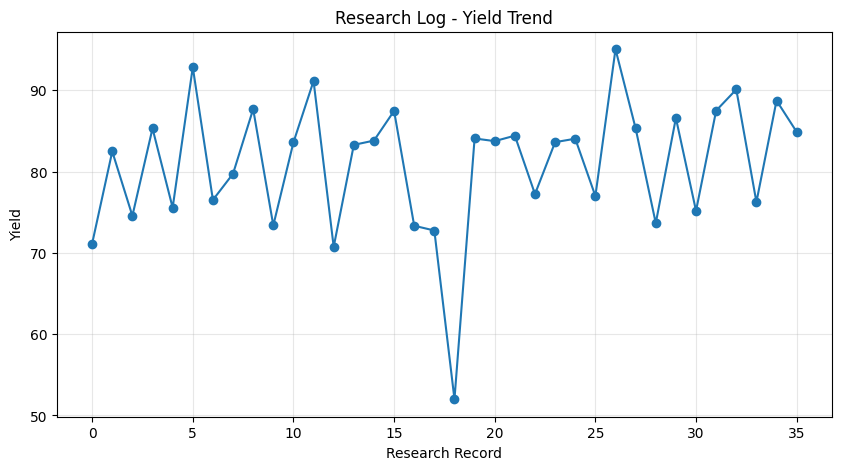

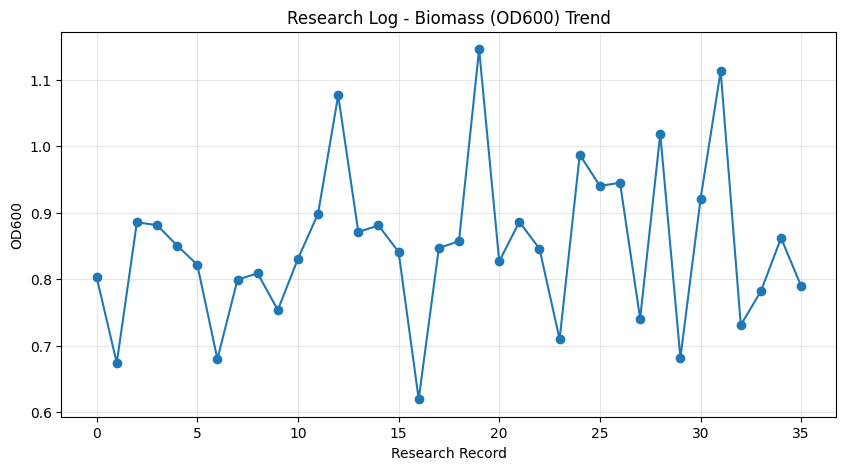

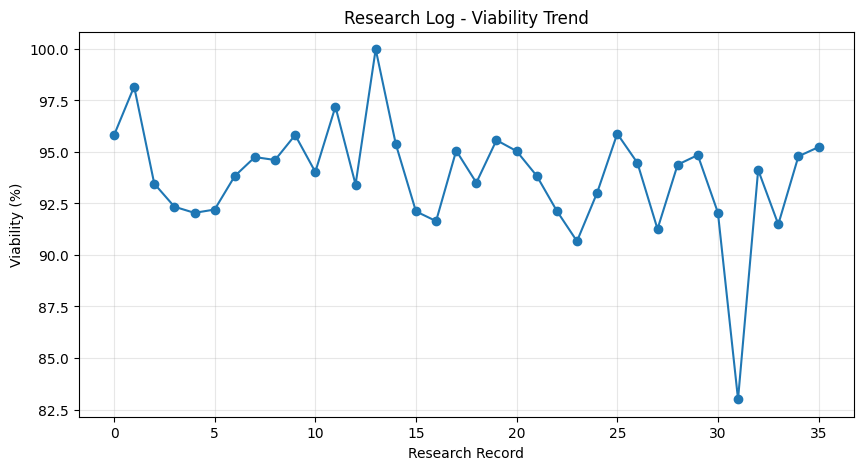

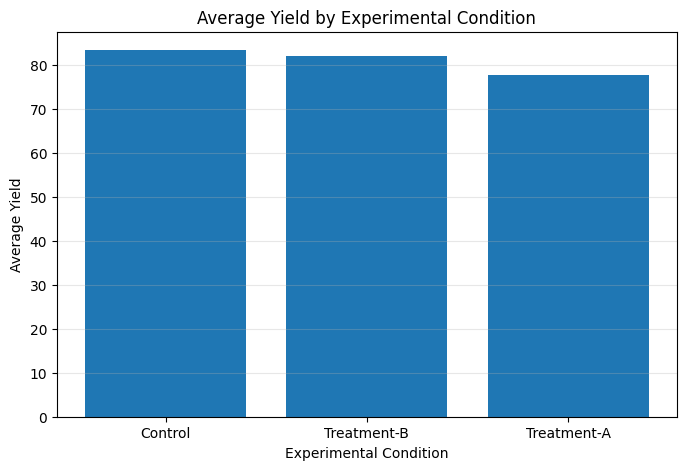

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. YIELD TREND
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    df.index,
    df["yield"],
    marker="o"
)

plt.title("Research Log - Yield Trend")
plt.xlabel("Research Record")
plt.ylabel("Yield")
plt.grid(True, alpha=0.3)

plt.show()


# ==========================================
# 2. OD600 / BIOMASS TREND
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    df.index,
    df["od600"],
    marker="o"
)

plt.title("Research Log - Biomass (OD600) Trend")
plt.xlabel("Research Record")
plt.ylabel("OD600")
plt.grid(True, alpha=0.3)

plt.show()


# ==========================================
# 3. VIABILITY TREND
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    df.index,
    df["viability_pct"],
    marker="o"
)

plt.title("Research Log - Viability Trend")
plt.xlabel("Research Record")
plt.ylabel("Viability (%)")
plt.grid(True, alpha=0.3)

plt.show()


# ==========================================
# 4. AVERAGE YIELD BY CONDITION
# ==========================================

condition_yield = (
    df.groupby("condition")["yield"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    condition_yield.index,
    condition_yield.values
)

plt.title("Average Yield by Experimental Condition")
plt.xlabel("Experimental Condition")
plt.ylabel("Average Yield")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

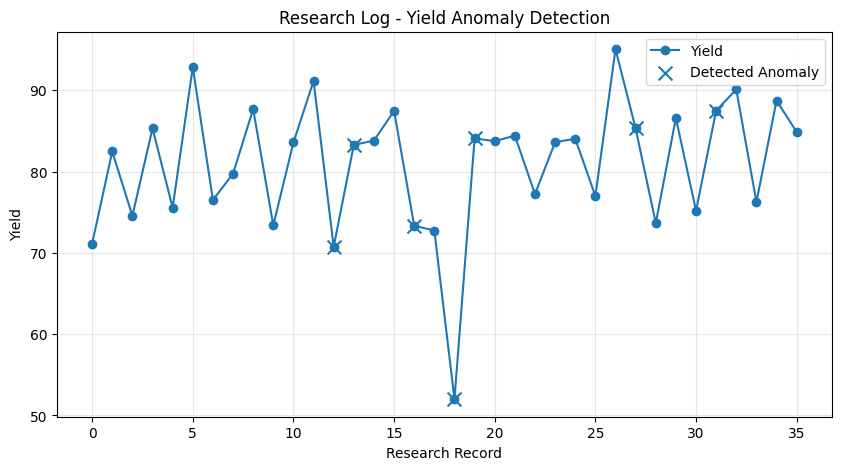

In [31]:
# ==========================================
# 5. ANOMALY DETECTION VISUALIZATION
# ==========================================

outlier_rows = quality_report["outlier_rows"]

plt.figure(figsize=(10, 5))

plt.plot(
    df.index,
    df["yield"],
    marker="o",
    label="Yield"
)

# Highlight detected outliers
if len(outlier_rows) > 0:

    plt.scatter(
        outlier_rows,
        df.loc[outlier_rows, "yield"],
        s=100,
        marker="x",
        label="Detected Anomaly"
    )

plt.title("Research Log - Yield Anomaly Detection")
plt.xlabel("Research Record")
plt.ylabel("Yield")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

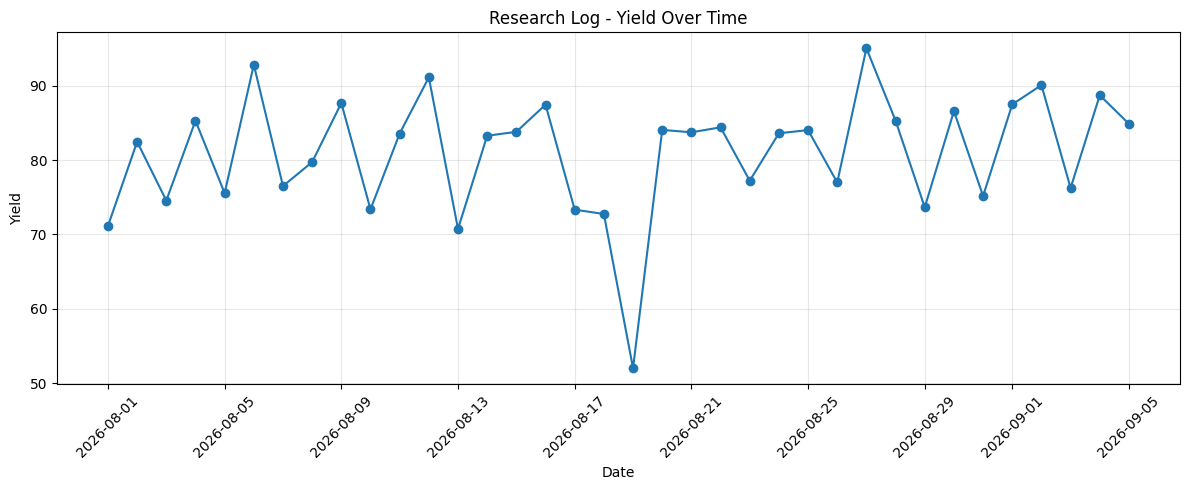

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["yield"],
    marker="o"
)

plt.title("Research Log - Yield Over Time")
plt.xlabel("Date")
plt.ylabel("Yield")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [33]:
# ==========================================
# CONDITION COMPARISON
# ==========================================

condition_stats = (
    df.groupby("condition")[
        ["yield", "od600", "viability_pct"]
    ]
    .mean()
)

print(condition_stats)

                 yield     od600  viability_pct
condition                                      
Control      83.340395  0.884965      94.020689
Treatment-A  77.753290  0.827382      93.468235
Treatment-B  82.034403  0.844889      93.953951


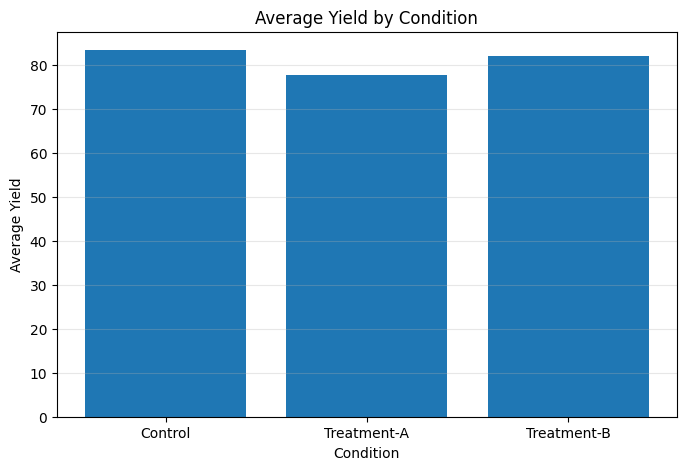

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(
    condition_stats.index,
    condition_stats["yield"]
)

plt.title("Average Yield by Condition")
plt.xlabel("Condition")
plt.ylabel("Average Yield")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()